Lab 1 — Text Processing & Tokenisation

In [24]:
# إعداد بيئة قابلة لإعادة التشغيل / Reproducible setup
import importlib.util
import subprocess
import sys

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2", "spacy": "3.8.7"}
missing = [name for name in PINNED if importlib.util.find_spec(name) is None]
if missing:
    packages = [f"{name}=={PINNED[name]}" for name in missing]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *packages])

print("Python:", sys.version.split()[0])
print("Environment ready / البيئة جاهزة")

Python: 3.13.15
Environment ready / البيئة جاهزة


جهزنا المكتبات التي نحتاجها وننشئ خمس نصوص غير حقيقه لتجربه وتحتوي على مسافه(مرحبــا\بكم"  ),
 نص عربي عادي(أهلاً وسهلاً بكم في برنامج بيان  ),
  بيانات حساسه مثل الايميل والتلفون واخيرا جمل بللغه الانجليزيه
  (Natural language processing connects text and models.  )وذلك لغرض الاختبار  

In [25]:
import html
import re
import unicodedata
from dataclasses import dataclass
from typing import Iterable

import numpy as np
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.pre_tokenizers import BertPreTokenizer
from tokenizers.processors import TemplateProcessing

SEED = 42
rng = np.random.default_rng(SEED)
samples = [
    "أهلاً وسهلاً بكم في برنامج بيان!",
    "مرحبــاً\u00a0بكم",
    "Contact us at learner@example.org",
    "للتجربة فقط: 0551234567",
    "Natural language processing connects text and models.",
]
print("Synthetic samples:", len(samples))

Synthetic samples: 5


**Unicode** هو معيار يعطي كل حرف او رمز
code poind
لغرض التميز ويسهل تمثيله بشكل موحد بين الانظمه مثلا حرف الالف يعرف من بين الانظمه بكود بوينت
unicode للاف =char': 'أ', 'code_point': 'U+0623',

In [26]:
def inspect_unicode(text: str) -> list[dict[str, str]]:
    return [
        {"char": ch, "code_point": f"U+{ord(ch):04X}", "name": unicodedata.name(ch, "UNKNOWN")}
        for ch in text
    ]

unicode_rows = inspect_unicode("أé")
for row in unicode_rows:
    print(row)
assert unicode_rows[0]["code_point"] == "U+0623"
print("Unicode inspection=PASS")

{'char': 'أ', 'code_point': 'U+0623', 'name': 'ARABIC LETTER ALEF WITH HAMZA ABOVE'}
{'char': 'é', 'code_point': 'U+00E9', 'name': 'LATIN SMALL LETTER E WITH ACUTE'}
Unicode inspection=PASS


mask_pii & TextRecord
raw_text & model_text
لابد ان يكون لدي نسخه اصليه لكي لايتم التعديل عليها وتضيعها  ونسخه مهياءه لدخول للمرحله القادمه
raw text   هي النسخه الاصليه ونحتفظ بها لرجوع لتدقيق واعاده المعالجه مثل مرحــــباه
لكن model text هي نسخه يتم تهيئتها لدخول الى Tokenizer
مثل مرحبا بعد التعديل
mask_pii يعني اخفاء البيانات الحساسه خلف رموز او صور او كلمات تدل عليها
normalization توحيد تمثيل النص عشان تكون الصياغه متكافئه باستخدام NFC او توحيد المسافات

In [27]:
ARABIC_DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED]")
TATWEEL = "\u0640"
WHITESPACE = re.compile(r"\s+")
HTML_TAG = re.compile(r"<[^>]+>")
EMAIL = re.compile(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b")
SAUDI_MOBILE = re.compile(r"(?<!\d)(?:\+?966|00966|0)?5\d{8}(?!\d)")

@dataclass(frozen=True)
class TextRecord:
    raw_text: str
    model_text: str


def mask_pii(text: str) -> str:
    return SAUDI_MOBILE.sub("<PHONE>", EMAIL.sub("<EMAIL>", text))

#
def prepare_text(text: str, *, remove_diacritics: bool = False, normalize_alef: bool = False) -> TextRecord:
    if not isinstance(text, str):
        raise TypeError("text must be a string")
        #removing the html tag
    raw = text
    model = unicodedata.normalize("NFC", html.unescape(text))
    #removing the tatweel
    model = HTML_TAG.sub(" ", model).replace(TATWEEL, "")
    if remove_diacritics:
        model = ARABIC_DIACRITICS.sub("", model)
    if normalize_alef:
        model = re.sub(r"[إأآٱ]", "ا", model)
    model = WHITESPACE.sub(" ", mask_pii(model)).strip()
    return TextRecord(raw_text=raw, model_text=model)

records = [prepare_text(text) for text in samples]
for record in records:
    print({"raw": record.raw_text, "model": record.model_text})
assert records[1].raw_text != records[1].model_text
#PII Masking
assert "learner@example.org" not in records[2].model_text
assert "0551234567" not in records[3].model_text
assert records[2].raw_text == samples[2]
print("Two-copy preprocessing contract=PASS")

{'raw': 'أهلاً وسهلاً بكم في برنامج بيان!', 'model': 'أهلاً وسهلاً بكم في برنامج بيان!'}
{'raw': 'مرحبــاً\xa0بكم', 'model': 'مرحباً بكم'}
{'raw': 'Contact us at learner@example.org', 'model': 'Contact us at <EMAIL>'}
{'raw': 'للتجربة فقط: 0551234567', 'model': 'للتجربة فقط: <PHONE>'}
{'raw': 'Natural language processing connects text and models.', 'model': 'Natural language processing connects text and models.'}
Two-copy preprocessing contract=PASS


## **spacy**
مكتبه لمعالجه اللغه الطبيعيه يقوم بتقسم الجمل ويحدد من اين تبدا ومن اين تنتهي

In [28]:
import spacy

sentence_nlp = spacy.blank("xx")
sentence_nlp.add_pipe("sentencizer")

def split_model_sentences(text: str) -> list[str]:
    protected = prepare_text(text).model_text
    return [sentence.text.strip() for sentence in sentence_nlp(protected).sents if sentence.text.strip()]

sentence_examples = {
    "ar": "الخدمة جيدة. لم يصل الرمز!",
    "en": "The portal stopped. Please retry.",
}
sentence_splits = {language: split_model_sentences(text) for language, text in sentence_examples.items()}
for language, sentences in sentence_splits.items():
    print(language, sentences)

abbreviation_probe = split_model_sentences("راجع د. أحمد. ثم أعد المحاولة.")
print("Known abbreviation probe / حالة تحتاج قاعدة إضافية:", abbreviation_probe)
assert sentence_splits["ar"] == ["الخدمة جيدة.", "لم يصل الرمز!"]
assert sentence_splits["en"] == ["The portal stopped.", "Please retry."]
print("SPACY_SENTENCE_PIPELINE=PASS")

ar ['الخدمة جيدة.', 'لم يصل الرمز!']
en ['The portal stopped.', 'Please retry.']
Known abbreviation probe / حالة تحتاج قاعدة إضافية: ['راجع د.', 'أحمد.', 'ثم أعد المحاولة.']
SPACY_SENTENCE_PIPELINE=PASS


### **Special Tokens**


In [29]:
special_tokens = ["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"]
known_tokens = [
    "أهلاً", "وسهلاً", "بكم", "في", "برنامج", "بيان", "!", "مرحبا",
    "Contact", "us", "at", "<", "EMAIL", ">", "Natural", "language",
    "processing", "connects", "text", "and", "models", ".",
]
vocab_tokens = special_tokens + known_tokens
vocab = {token: idx for idx, token in enumerate(vocab_tokens)}
local_tokenizer = Tokenizer(WordPiece(vocab=vocab, unk_token="[UNK]"))
local_tokenizer.pre_tokenizer = BertPreTokenizer()
local_tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    special_tokens=[("[CLS]", vocab["[CLS]"]), ("[SEP]", vocab["[SEP]"])],
)
for record in records:
    encoded = local_tokenizer.encode(record.model_text)
    print(record.model_text)
    print("tokens:", encoded.tokens)
    print("ids:   ", encoded.ids)
assert local_tokenizer.encode("مرحبا بكم").tokens == ["[CLS]", "مرحبا", "بكم", "[SEP]"]
print("Local WordPiece demonstration=PASS")

أهلاً وسهلاً بكم في برنامج بيان!
tokens: ['[CLS]', 'أهلاً', 'وسهلاً', 'بكم', 'في', 'برنامج', 'بيان', '!', '[SEP]']
ids:    [2, 5, 6, 7, 8, 9, 10, 11, 3]
مرحباً بكم
tokens: ['[CLS]', '[UNK]', 'بكم', '[SEP]']
ids:    [2, 1, 7, 3]
Contact us at <EMAIL>
tokens: ['[CLS]', 'Contact', 'us', 'at', '<', 'EMAIL', '>', '[SEP]']
ids:    [2, 13, 14, 15, 16, 17, 18, 3]
للتجربة فقط: <PHONE>
tokens: ['[CLS]', '[UNK]', '[UNK]', '[UNK]', '<', '[UNK]', '>', '[SEP]']
ids:    [2, 1, 1, 1, 16, 1, 18, 3]
Natural language processing connects text and models.
tokens: ['[CLS]', 'Natural', 'language', 'processing', 'connects', 'text', 'and', 'models', '.', '[SEP]']
ids:    [2, 19, 20, 21, 22, 23, 24, 25, 26, 3]
Local WordPiece demonstration=PASS


### **قياس الTokenizer**
كلما زادت القيمة، فهذا يعني أن النص يُجزّأ إلى Tokens أكثر بالنسبة لعدد الكلمات

In [30]:
def word_count(text: str) -> int:
    return max(1, len(text.split()))


def token_fertility(tokenizer: Tokenizer, text: str) -> float:
    tokens = tokenizer.encode(text).tokens
    content = [t for t in tokens if t not in {"[CLS]", "[SEP]", "[PAD]"}]
    return len(content) / word_count(text)


def truncation_rate(tokenizer: Tokenizer, texts: Iterable[str], max_length: int) -> float:
    texts = list(texts)
    if not texts:
        raise ValueError("texts must not be empty")
    return sum(len(tokenizer.encode(t).ids) > max_length for t in texts) / len(texts)

model_texts = [record.model_text for record in records]
fertilities = [token_fertility(local_tokenizer, text) for text in model_texts]
rate_at_10 = truncation_rate(local_tokenizer, model_texts, max_length=10)
print("fertility per sample:", [round(x, 2) for x in fertilities])
print("mean fertility:", round(float(np.mean(fertilities)), 2))
print("truncation rate @10:", f"{rate_at_10:.0%}")
assert all(x > 0 for x in fertilities)
assert 0.0 <= rate_at_10 <= 1.0
print("Tokenisation metrics=PASS")

fertility per sample: [1.17, 1.0, 1.5, 2.0, 1.14]
mean fertility: 1.36
truncation rate @10: 0%
Tokenisation metrics=PASS


In [31]:
arabic_texts = [
    records[0].model_text,
    records[1].model_text,
]

english_texts = [
    records[4].model_text,
]

arabic_fertility = [
    token_fertility(local_tokenizer, text)
    for text in arabic_texts
]

english_fertility = [
    token_fertility(local_tokenizer, text)
    for text in english_texts
]

print(
    "Arabic fertility:",
    [round(x, 2) for x in arabic_fertility]
)

print(
    "Arabic mean fertility:",
    round(float(np.mean(arabic_fertility)), 2)
)

print(
    "English fertility:",
    [round(x, 2) for x in english_fertility]
)

print(
    "English mean fertility:",
    round(float(np.mean(english_fertility)), 2)
)

Arabic fertility: [1.17, 1.0]
Arabic mean fertility: 1.08
English fertility: [1.14]
English mean fertility: 1.14


## **تحويلـToken IDs إلى Embedding**


In [32]:
MAX_LENGTH = 12
local_tokenizer.enable_truncation(max_length=MAX_LENGTH)
local_tokenizer.enable_padding(length=MAX_LENGTH, pad_id=vocab["[PAD]"], pad_token="[PAD]")
batch = [local_tokenizer.encode(text) for text in model_texts[:2]]
input_ids = np.array([item.ids for item in batch], dtype=np.int64)
attention_mask = np.array([item.attention_mask for item in batch], dtype=np.int64)
embedding_table = rng.normal(0.0, 0.02, size=(len(vocab), 8))
embeddings = embedding_table[input_ids]
print("input_ids shape:", input_ids.shape)
print("attention_mask shape:", attention_mask.shape)
print("embeddings shape:", embeddings.shape)
print("first attention mask:", attention_mask[0].tolist())
assert input_ids.shape == (2, MAX_LENGTH)
assert attention_mask.shape == input_ids.shape
assert embeddings.shape == (2, MAX_LENGTH, 8)
print("IDs-to-embeddings pipeline=PASS")

input_ids shape: (2, 12)
attention_mask shape: (2, 12)
embeddings shape: (2, 12, 8)
first attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0]
IDs-to-embeddings pipeline=PASS


### **mBERT tokenizer comparison for Arabic-English text**

In [33]:
try:
    from transformers import AutoTokenizer
    hf_tokenizer = AutoTokenizer.from_pretrained("google-bert/bert-base-multilingual-cased", use_fast=True)
    comparison_text = "معالجة اللغة الطبيعية مفيدة Natural language processing is useful"
    hf_tokens = hf_tokenizer.tokenize(comparison_text)
    print("mBERT tokens:", hf_tokens)
    print("mBERT token count:", len(hf_tokens))
    print("Fast tokenizer:", hf_tokenizer.is_fast)
except Exception as exc:
    print("Optional mBERT download unavailable; continue with Core.")
    print("Reason:", type(exc).__name__)

mBERT tokens: ['مع', '##الجة', 'اللغة', 'الطبيعية', 'م', '##فيد', '##ة', 'Natural', 'language', 'processing', 'is', 'useful']
mBERT token count: 12
Fast tokenizer: True


Dictionary اسمه core_checks


In [34]:
core_checks = {
    "unicode": unicode_rows[0]["code_point"] == "U+0623",
    "spacy_sentence_pipeline": all(len(value) == 2 for value in sentence_splits.values()),
    "raw_copy_preserved": records[2].raw_text == samples[2],
    "pii_masked": "<EMAIL>" in records[2].model_text and "<PHONE>" in records[3].model_text,
    "token_metrics": all(x > 0 for x in fertilities) and 0 <= rate_at_10 <= 1,
    "embedding_shape": embeddings.shape == (2, MAX_LENGTH, 8),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK1_CORE=PASS")

unicode: PASS
spacy_sentence_pipeline: PASS
raw_copy_preserved: PASS
pii_masked: PASS
token_metrics: PASS
embedding_shape: PASS
DAY1_NOTEBOOK1_CORE=PASS


## **lab 2 **
تجهيز البيئه

In [35]:
import importlib.metadata
import subprocess
import sys
import math
import numpy as np

PINNED = {"transformers": "5.15.1", "tokenizers": "0.22.2"}
to_install = []
for distribution, expected in PINNED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        to_install.append(f"{distribution}=={expected}")
if to_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--quiet", *to_install])

SEED = 42
rng = np.random.default_rng(SEED)
print("NumPy:", np.__version__)
print("Pinned:", {name: importlib.metadata.version(name) for name in PINNED})
print("Core runtime ready / بيئة Core جاهزة")

NumPy: 2.1.3
Pinned: {'transformers': '5.15.1', 'tokenizers': '0.22.2'}
Core runtime ready / بيئة Core جاهزة


## **Attention**
تستخدم (Query) و (Key) و(Value)
 للحصول على scores نقارن الKey with query
 بعدها نستخدم softmax لتحويل score الى وزن
 ويكون مجموع كل صف واحد او صفر

  

In [36]:
def softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    shifted = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(shifted)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def scaled_dot_product_attention(
    q: np.ndarray,
    k: np.ndarray,
    v: np.ndarray,
    keep_mask: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    if q.shape[-1] != k.shape[-1]:
        raise ValueError("Q and K must share d_k")
    if k.shape[-2] != v.shape[-2]:
        raise ValueError("K and V must share sequence length")
    scores = q @ np.swapaxes(k, -1, -2) / math.sqrt(q.shape[-1])
    #يسمح لنا لاحقًا بمنع Attention عن بعض الـKeys
    if keep_mask is not None:
        mask = np.asarray(keep_mask, dtype=bool)
        try:
            mask = np.broadcast_to(mask, scores.shape)
        except ValueError as exc:
            raise ValueError("keep_mask is not broadcastable to scores") from exc
        if np.any(mask.sum(axis=-1) == 0):
            raise ValueError("Every query row must keep at least one key")
        scores = np.where(mask, scores, -np.inf)
    weights = softmax(scores, axis=-1)
    output = weights @ v
    return output, weights, scores

q = np.array([[1.0, 0.0], [0.0, 1.0]])
k = np.array([[1.0, 0.0], [0.0, 1.0], [1.0, 1.0]])
v = np.array([[10.0, 0.0], [0.0, 10.0], [5.0, 5.0]])
output, weights, scores = scaled_dot_product_attention(q, k, v)
print("scores shape:", scores.shape)
print("weights:\n", np.round(weights, 3))
print("row sums:", weights.sum(axis=-1))
print("output:\n", np.round(output, 3))
assert output.shape == (2, 2)
assert np.allclose(weights.sum(axis=-1), 1.0)
print("Scaled attention=PASS")

scores shape: (2, 3)
weights:
 [[0.401 0.198 0.401]
 [0.198 0.401 0.401]]
row sums: [1. 1.]
output:
 [[6.017 3.983]
 [3.983 6.017]]
Scaled attention=PASS


In [37]:
def entropy(probabilities: np.ndarray) -> float:
    p = np.clip(probabilities, 1e-12, 1.0)
    return float(-np.sum(p * np.log(p), axis=-1).mean())

q_big = rng.normal(size=(6, 64))
k_big = rng.normal(size=(6, 64))
raw_scores = q_big @ k_big.T
unscaled_weights = softmax(raw_scores)
scaled_weights = softmax(raw_scores / math.sqrt(q_big.shape[-1]))
print("mean entropy without scaling:", round(entropy(unscaled_weights), 3))
print("mean entropy with scaling:   ", round(entropy(scaled_weights), 3))
print("Scaling comparison complete")

mean entropy without scaling: 0.379
mean entropy with scaling:    1.624
Scaling comparison complete


### **Mask**
Mask لا يحذف الـTokens.

هو فقط يمنع الـAttention من إعطاء وزن لبعض المواقع

In [38]:
causal_keep_mask = np.tril(np.ones((2, 3), dtype=bool))
masked_output, masked_weights, _ = scaled_dot_product_attention(q, k, v, keep_mask=causal_keep_mask)
print("keep mask:\n", causal_keep_mask.astype(int))
print("masked weights:\n", np.round(masked_weights, 3))
assert masked_weights[0, 1] == 0.0
assert masked_weights[0, 2] == 0.0
print("Mask semantics=PASS")

keep mask:
 [[1 0 0]
 [1 1 0]]
masked weights:
 [[1.   0.   0.  ]
 [0.33 0.67 0.  ]]
Mask semantics=PASS


## **Multi-Head Attention**
يسمح للنموذج بالتركيز على علاقات مختلفة بين الكلمات في الوقت نفسه بدل الاعتماد على Attention واحد فقط

In [39]:
def split_heads(x: np.ndarray, num_heads: int) -> np.ndarray:
    batch, seq_len, d_model = x.shape
    if d_model % num_heads != 0:
        raise ValueError("d_model must be divisible by num_heads")
    d_head = d_model // num_heads
    return x.reshape(batch, seq_len, num_heads, d_head).transpose(0, 2, 1, 3)


def combine_heads(x: np.ndarray) -> np.ndarray:
    batch, num_heads, seq_len, d_head = x.shape
    return x.transpose(0, 2, 1, 3).reshape(batch, seq_len, num_heads * d_head)

x = rng.normal(size=(2, 5, 12))
heads = split_heads(x, num_heads=3)
combined = combine_heads(heads)
print("input:", x.shape)
print("split:", heads.shape, "= (batch, heads, tokens, d_head)")
print("combined:", combined.shape)
assert heads.shape == (2, 3, 5, 4)
assert np.allclose(combined, x)
print("Multi-head shape journey=PASS")

input: (2, 5, 12)
split: (2, 3, 5, 4) = (batch, heads, tokens, d_head)
combined: (2, 5, 12)
Multi-head shape journey=PASS


In [40]:
try:
    import torch
    torch.manual_seed(SEED)
    layer = torch.nn.TransformerEncoderLayer(
        d_model=12, nhead=3, dim_feedforward=24,
        dropout=0.0, batch_first=True, norm_first=False,
    )
    layer.eval()
    torch_x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        encoder_output = layer(torch_x)
    print("PyTorch encoder output:", tuple(encoder_output.shape))
    assert tuple(encoder_output.shape) == (2, 5, 12)
    print("Optional encoder layer=PASS")
except ModuleNotFoundError:
    print("PyTorch is optional here; NumPy Core remains complete.")

PyTorch encoder output: (2, 5, 12)
Optional encoder layer=PASS


In [41]:
try:
    import torch
    import torch.nn.functional as F
    tq = torch.tensor(q, dtype=torch.float64)[None, None, :, :]
    tk = torch.tensor(k, dtype=torch.float64)[None, None, :, :]
    tv = torch.tensor(v, dtype=torch.float64)[None, None, :, :]
    torch_result = F.scaled_dot_product_attention(tq, tk, tv, dropout_p=0.0)
    np_result = output[None, None, :, :]
    max_difference = float(np.max(np.abs(torch_result.numpy() - np_result)))
    print("max NumPy/PyTorch difference:", f"{max_difference:.3e}")
    assert max_difference < 1e-9
    print("NumPy/PyTorch parity=PASS")
except ModuleNotFoundError:
    print("PyTorch unavailable; parity check skipped without affecting Core.")

max NumPy/PyTorch difference: 4.441e-16
NumPy/PyTorch parity=PASS


مقارنة checkpointين من عائلة BERT وحساب عدد الـparameters والتأكد من تأثير حجم الـvocabular

In [42]:
from transformers import AutoConfig

AUDIT_CHECKPOINTS = [
    "google-bert/bert-base-multilingual-cased",
    "CAMeL-Lab/bert-base-arabic-camelbert-da",
]
EXPECTED_TOTALS = {
    "google-bert/bert-base-multilingual-cased": 177_853_440,
    "CAMeL-Lab/bert-base-arabic-camelbert-da": 109_081_344,
}

def bert_parameter_audit(model_id: str) -> dict:
    config = AutoConfig.from_pretrained(model_id)
    assert config.model_type == "bert"
    hidden = config.hidden_size
    intermediate = config.intermediate_size
    embeddings = (
        config.vocab_size * hidden
        + config.max_position_embeddings * hidden
        + config.type_vocab_size * hidden
        + 2 * hidden
    )
    per_layer = (
        3 * (hidden * hidden + hidden)
        + (hidden * hidden + hidden) + 2 * hidden
        + (hidden * intermediate + intermediate)
        + (intermediate * hidden + hidden) + 2 * hidden
    )
    pooler = hidden * hidden + hidden
    total = embeddings + config.num_hidden_layers * per_layer + pooler
    return {
        "model_id": model_id, "vocab_size": config.vocab_size,
        "total_parameters": total,
        "embedding_share": embeddings / total,
    }

parameter_audits = [bert_parameter_audit(model_id) for model_id in AUDIT_CHECKPOINTS]
for item in parameter_audits:
    print(
        f'{item["model_id"]} | vocab={item["vocab_size"]:,} | '
        f'total={item["total_parameters"]:,} | '
        f'embeddings={item["embedding_share"]:.1%}'
    )
assert all(item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]] for item in parameter_audits)
print("TWO_CHECKPOINT_PARAMETER_AUDIT=PASS")

google-bert/bert-base-multilingual-cased | vocab=119,547 | total=177,853,440 | embeddings=51.8%
CAMeL-Lab/bert-base-arabic-camelbert-da | vocab=30,000 | total=109,081,344 | embeddings=21.5%
TWO_CHECKPOINT_PARAMETER_AUDIT=PASS


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Model: distilbert/distilbert-base-multilingual-cased
Parameters: 134,734,080
Hidden-state shape: (2, 10, 768)
Attention tensor [batch, heads, query, key]: (2, 12, 10, 10)
Arabic tokens: ['[CLS]', 'ال', '##خدمة', 'لم', 'ت', '##ت', '##أ', '##خر', '.', '[SEP]']
Row-sum range: 0.9999998211860657 1.0


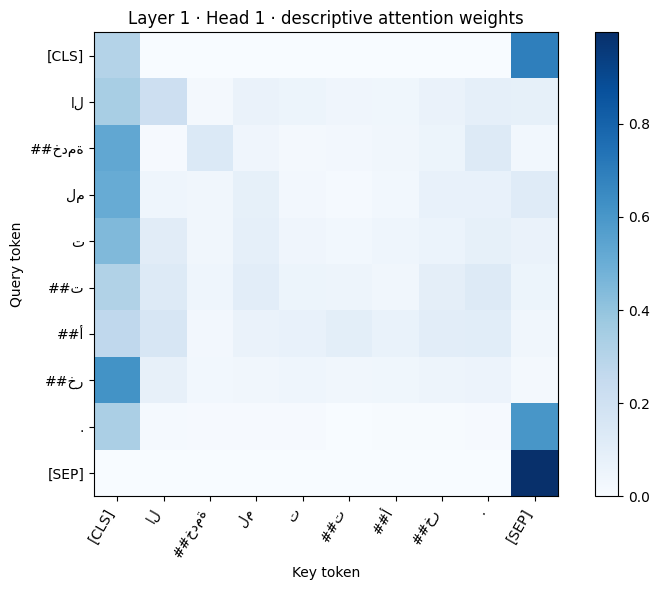

ACTUAL_TRANSFORMER_FORWARD=PASS


In [43]:
import torch
import matplotlib.pyplot as plt
from transformers import AutoModel, AutoTokenizer
from transformers.utils import logging as hf_logging

hf_logging.set_verbosity_error()
ACTUAL_MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
actual_tokenizer = AutoTokenizer.from_pretrained(ACTUAL_MODEL_ID, use_fast=True)
actual_model = AutoModel.from_pretrained(ACTUAL_MODEL_ID, attn_implementation="eager")
actual_model.eval()

sentences = ["الخدمة لم تتأخر.", "The service was not delayed."]
encoded = actual_tokenizer(sentences, padding=True, truncation=True, max_length=32, return_tensors="pt")
with torch.no_grad():
    forward = actual_model(**encoded, output_attentions=True)

parameter_count = sum(parameter.numel() for parameter in actual_model.parameters())
attention_shape = tuple(forward.attentions[0].shape)
hidden_shape = tuple(forward.last_hidden_state.shape)
arabic_tokens = actual_tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])
valid_length = int(encoded["attention_mask"][0].sum())
head_weights = forward.attentions[0][0, 0, :valid_length, :valid_length].cpu().numpy()

print(f"Model: {ACTUAL_MODEL_ID}")
print(f"Parameters: {parameter_count:,}")
print("Hidden-state shape:", hidden_shape)
print("Attention tensor [batch, heads, query, key]:", attention_shape)
print("Arabic tokens:", arabic_tokens[:valid_length])
print("Row-sum range:", float(head_weights.sum(-1).min()), float(head_weights.sum(-1).max()))

figure, axis = plt.subplots(figsize=(8, 6))
image = axis.imshow(head_weights, cmap="Blues", vmin=0.0)
axis.set_xticks(range(valid_length), arabic_tokens[:valid_length], rotation=60, ha="right")
axis.set_yticks(range(valid_length), arabic_tokens[:valid_length])
axis.set_xlabel("Key token")
axis.set_ylabel("Query token")
axis.set_title("Layer 1 · Head 1 · descriptive attention weights")
figure.colorbar(image, ax=axis, fraction=0.046)
figure.tight_layout()
plt.show()

assert parameter_count > 100_000_000
assert hidden_shape[:2] == tuple(encoded["input_ids"].shape)
assert attention_shape[0] == 2 and attention_shape[2] == attention_shape[3]
assert np.allclose(head_weights.sum(-1), 1.0, atol=1e-5)
print("ACTUAL_TRANSFORMER_FORWARD=PASS")

In [44]:
core_checks = {
    "weights_sum_to_one": np.allclose(weights.sum(axis=-1), 1.0),
    "two_checkpoint_parameter_audit": len(parameter_audits) == 2 and all(
        item["total_parameters"] == EXPECTED_TOTALS[item["model_id"]]
        for item in parameter_audits
    ),
    "actual_forward": parameter_count > 100_000_000 and len(forward.attentions) > 0,
    "output_shape": output.shape == (2, 2),
    "masked_positions_zero": masked_weights[0, 1] == 0 and masked_weights[0, 2] == 0,
    "heads_round_trip": np.allclose(combined, x),
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY1_NOTEBOOK2_CORE=PASS")

weights_sum_to_one: PASS
two_checkpoint_parameter_audit: PASS
actual_forward: PASS
output_shape: PASS
masked_positions_zero: PASS
heads_round_trip: PASS
DAY1_NOTEBOOK2_CORE=PASS


## **Lab 3**

In [45]:
# تثبيت نسخ اليوم الثاني فقط عند الحاجة
import importlib.metadata
import importlib.util
import subprocess
import sys

REQUIRED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "scikit-learn": "1.9.0",
}
needs_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        needs_install.append(f"{distribution}=={expected}")

if needs_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needs_install])

if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required. Open this notebook in Google Colab.")

print("Python:", sys.version.split()[0])
print("Environment ready / البيئة جاهزة")

Python: 3.13.15
Environment ready / البيئة جاهزة


In [1]:
import csv
import io
import json
import math
import os
import random
import urllib.request
from collections import Counter
from pathlib import Path

import numpy as np
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, f1_score
from sklearn.pipeline import make_pipeline
from sklearn.svm import LinearSVC
from torch.optim import AdamW
from transformers import AutoModelForSequenceClassification, AutoTokenizer

os.environ["TOKENIZERS_PARALLELISM"] = "false"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [2]:
DATA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_classification.csv"
FALLBACK_ROWS = [{"example_id":"F-001","group_id":"DG-A","split":"train","language":"ar","text":"تعذر تسجيل الدخول إلى البوابة","topic":"digital_service","sentiment":"negative"},{"example_id":"F-002","group_id":"DG-A","split":"train","language":"en","text":"I cannot sign in to the portal","topic":"digital_service","sentiment":"negative"},{"example_id":"F-003","group_id":"DG-B","split":"train","language":"ar","text":"الخدمة الإلكترونية سريعة وواضحة","topic":"digital_service","sentiment":"positive"},{"example_id":"F-004","group_id":"DG-B","split":"train","language":"en","text":"The online service is clear and fast","topic":"digital_service","sentiment":"positive"},{"example_id":"F-005","group_id":"PG-A","split":"train","language":"ar","text":"أحتاج معرفة حالة طلب التصريح","topic":"permit","sentiment":"neutral"},{"example_id":"F-006","group_id":"PG-A","split":"train","language":"en","text":"I need the status of my permit request","topic":"permit","sentiment":"neutral"},{"example_id":"F-007","group_id":"PG-B","split":"train","language":"ar","text":"تمت الموافقة على التصريح اليوم","topic":"permit","sentiment":"positive"},{"example_id":"F-008","group_id":"PG-B","split":"train","language":"en","text":"The permit was approved today","topic":"permit","sentiment":"positive"},{"example_id":"F-009","group_id":"HG-A","split":"train","language":"ar","text":"تأخر موعد العيادة هذا الصباح","topic":"health","sentiment":"negative"},{"example_id":"F-010","group_id":"HG-A","split":"train","language":"en","text":"My clinic appointment was delayed","topic":"health","sentiment":"negative"},{"example_id":"F-011","group_id":"HG-B","split":"train","language":"ar","text":"كانت خدمة العيادة ممتازة","topic":"health","sentiment":"positive"},{"example_id":"F-012","group_id":"HG-B","split":"train","language":"en","text":"The clinic service was excellent","topic":"health","sentiment":"positive"},{"example_id":"F-013","group_id":"TG-A","split":"train","language":"ar","text":"الحافلة لم تصل في الوقت المحدد","topic":"transport","sentiment":"negative"},{"example_id":"F-014","group_id":"TG-A","split":"train","language":"en","text":"The bus did not arrive on time","topic":"transport","sentiment":"negative"},{"example_id":"F-015","group_id":"TG-B","split":"train","language":"ar","text":"كانت الرحلة مريحة ومنظمة","topic":"transport","sentiment":"positive"},{"example_id":"F-016","group_id":"TG-B","split":"train","language":"en","text":"The trip was comfortable and organised","topic":"transport","sentiment":"positive"},{"example_id":"F-017","group_id":"DG-V","split":"validation","language":"ar","text":"لم يصل رمز التحقق الرقمي","topic":"digital_service","sentiment":"negative"},{"example_id":"F-018","group_id":"PG-V","split":"validation","language":"en","text":"How can I renew the permit","topic":"permit","sentiment":"neutral"},{"example_id":"F-019","group_id":"HG-V","split":"validation","language":"ar","text":"أحتاج إعادة جدولة الموعد الصحي","topic":"health","sentiment":"neutral"},{"example_id":"F-020","group_id":"TG-V","split":"validation","language":"en","text":"The bus route has changed","topic":"transport","sentiment":"neutral"},{"example_id":"F-021","group_id":"DG-T","split":"test","language":"en","text":"The verification code did not arrive","topic":"digital_service","sentiment":"negative"},{"example_id":"F-022","group_id":"PG-T","split":"test","language":"ar","text":"تأخر إصدار التصريح المطلوب","topic":"permit","sentiment":"negative"},{"example_id":"F-023","group_id":"HG-T","split":"test","language":"en","text":"The clinic appointment was cancelled","topic":"health","sentiment":"negative"},{"example_id":"F-024","group_id":"TG-T","split":"test","language":"ar","text":"توقفت الحافلة قبل المحطة","topic":"transport","sentiment":"negative"}]

try:
    with urllib.request.urlopen(DATA_URL, timeout=20) as response:
        text = response.read().decode("utf-8")
    rows = list(csv.DictReader(io.StringIO(text)))
    DATA_SOURCE = "github_course_file"
except Exception as exc:
    rows = FALLBACK_ROWS
    DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

print("Data source:", DATA_SOURCE)
print("Rows:", len(rows))
print("Topics:", Counter(row["topic"] for row in rows))
assert len(rows) >= 24
assert {"ar", "en"} <= {row["language"] for row in rows}

Data source: github_course_file
Rows: 40
Topics: Counter({'digital_service': 10, 'permit': 10, 'health': 10, 'transport': 10})


In [3]:
def validate_splits(rows):
    required = {"train", "validation", "test"}
    group_owner = {}
    labels_by_split = {name: set() for name in required}
    counts = Counter()
    for row in rows:
        split, group, label = row["split"], row["group_id"], row["topic"]
        if split not in required:
            raise ValueError(f"Unknown split: {split}")
        previous = group_owner.setdefault(group, split)
        if previous != split:
            raise ValueError(f"Group leakage: {group}")
        labels_by_split[split].add(label)
        counts[split] += 1
    all_labels = set().union(*labels_by_split.values())
    for split in required:
        if labels_by_split[split] != all_labels:
            raise ValueError(f"Missing label in {split}")
    return {
        "rows": dict(counts),
        "groups": len(group_owner),
        "labels": sorted(all_labels),
        "group_overlap": 0,
    }

split_report = validate_splits(rows)
print(json.dumps(split_report, ensure_ascii=False, indent=2))
assert split_report["group_overlap"] == 0
print("Split contract=PASS")

{
  "rows": {
    "train": 24,
    "validation": 8,
    "test": 8
  },
  "groups": 20,
  "labels": [
    "digital_service",
    "health",
    "permit",
    "transport"
  ],
  "group_overlap": 0
}
Split contract=PASS


In [4]:
train_rows = [row for row in rows if row["split"] == "train"]
validation_rows = [row for row in rows if row["split"] == "validation"]
test_rows = [row for row in rows if row["split"] == "test"]
LABELS = sorted({row["topic"] for row in rows})
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}

baseline = make_pipeline(
    TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=1),
    LinearSVC(random_state=SEED),
)
baseline.fit(
    [row["text"] for row in train_rows],
    [row["topic"] for row in train_rows],
)
baseline_val_pred = baseline.predict([row["text"] for row in validation_rows])
baseline_val_f1 = f1_score(
    [row["topic"] for row in validation_rows],
    baseline_val_pred,
    labels=LABELS,
    average="macro",
    zero_division=0,
)
print("Baseline validation macro-F1 (MEASURED_SMOKE):", round(baseline_val_f1, 4))
assert 0.0 <= baseline_val_f1 <= 1.0
print("Baseline=PASS")

Baseline validation macro-F1 (MEASURED_SMOKE): 0.6667
Baseline=PASS


In [5]:
MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
MAX_LENGTH = 64
BATCH_SIZE = 4
NUM_EPOCHS = 2 if DEVICE.type == "cuda" else 12

try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_ID,
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )
except Exception as exc:
    raise RuntimeError(
        "Checkpoint download failed. Reconnect the runtime and run this cell once. "
        "No API key is required."
    ) from exc

TRAINING_MODE = "full_finetune" if DEVICE.type == "cuda" else "partial_finetune_cpu"
if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True

model.to(DEVICE)
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print("Training mode:", TRAINING_MODE)
print("Epochs:", NUM_EPOCHS)
print(f"Trainable parameters: {trainable:,} / {total:,}")
assert trainable > 0

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training mode: partial_finetune_cpu
Epochs: 12
Trainable parameters: 7,681,540 / 135,327,748


In [6]:
def iter_batches(examples, batch_size, *, shuffle=False, seed=SEED):
    indexes = np.arange(len(examples))
    if shuffle:
        np.random.default_rng(seed).shuffle(indexes)
    for start in range(0, len(indexes), batch_size):
        yield [examples[index] for index in indexes[start:start + batch_size]]


def encode_batch(batch):
    encoded = tokenizer(
        [row["text"] for row in batch],
        padding=True,
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    encoded["labels"] = torch.tensor(
        [label2id[row["topic"]] for row in batch], dtype=torch.long
    )
    return {key: value.to(DEVICE) for key, value in encoded.items()}


def predict(examples):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in iter_batches(examples, BATCH_SIZE):
            encoded = encode_batch(batch)
            logits = model(**encoded).logits
            predictions.extend(logits.argmax(-1).cpu().tolist())
    return [id2label[index] for index in predictions]

print("Batch functions=PASS")

Batch functions=PASS


In [7]:
learning_rate = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
trainable_parameters = [p for p in model.parameters() if p.requires_grad]
optimizer = AdamW(trainable_parameters, lr=learning_rate)
losses = []
train_steps = 0
epoch_history = []
best_validation_f1 = -1.0
best_epoch = 0
best_trainable_state = None

for epoch_index in range(NUM_EPOCHS):
    model.train()
    epoch_losses = []
    for batch in iter_batches(
        train_rows, BATCH_SIZE, shuffle=True, seed=SEED + epoch_index + 1
    ):
        optimizer.zero_grad(set_to_none=True)
        encoded = encode_batch(batch)
        output = model(**encoded)
        loss = output.loss
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite training loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(trainable_parameters, max_norm=1.0)
        optimizer.step()
        loss_value = float(loss.detach().cpu())
        losses.append(loss_value)
        epoch_losses.append(loss_value)
        train_steps += 1

    epoch_predictions = predict(validation_rows)
    epoch_f1 = f1_score(
        [row["topic"] for row in validation_rows], epoch_predictions,
        labels=LABELS, average="macro", zero_division=0,
    )
    epoch_history.append({
        "epoch": epoch_index + 1,
        "mean_loss": float(np.mean(epoch_losses)),
        "validation_macro_f1": float(epoch_f1),
    })
    if epoch_f1 > best_validation_f1:
        best_validation_f1 = float(epoch_f1)
        best_epoch = epoch_index + 1
        if TRAINING_MODE == "partial_finetune_cpu":
            best_trainable_state = {
                name: parameter.detach().cpu().clone()
                for name, parameter in model.named_parameters()
                if parameter.requires_grad
            }
    print(
        f"epoch={epoch_index + 1:02d} mean_loss={np.mean(epoch_losses):.4f} "
        f"validation_macro_f1={epoch_f1:.4f}"
    )

if best_trainable_state is not None:
    with torch.no_grad():
        for name, parameter in model.named_parameters():
            if name in best_trainable_state:
                parameter.copy_(best_trainable_state[name].to(parameter.device))
    selected_epoch = best_epoch
else:
    selected_epoch = NUM_EPOCHS

assert train_steps >= 1 and all(math.isfinite(value) for value in losses)
assert any(parameter.requires_grad for parameter in model.base_model.parameters())
print("Transformer optimizer steps=PASS", {"steps": train_steps, "selected_epoch": selected_epoch})

epoch=01 mean_loss=1.4031 validation_macro_f1=0.2917
epoch=02 mean_loss=1.3156 validation_macro_f1=0.4167
epoch=03 mean_loss=1.2396 validation_macro_f1=0.4167
epoch=04 mean_loss=1.1272 validation_macro_f1=0.6250
epoch=05 mean_loss=0.9523 validation_macro_f1=0.6250
epoch=06 mean_loss=0.7202 validation_macro_f1=0.7500
epoch=07 mean_loss=0.4770 validation_macro_f1=0.8667
epoch=08 mean_loss=0.2488 validation_macro_f1=0.8667
epoch=09 mean_loss=0.1160 validation_macro_f1=1.0000
epoch=10 mean_loss=0.0552 validation_macro_f1=1.0000
epoch=11 mean_loss=0.0225 validation_macro_f1=1.0000
epoch=12 mean_loss=0.0115 validation_macro_f1=0.8667
Transformer optimizer steps=PASS {'steps': 72, 'selected_epoch': 9}


In [8]:
transformer_val_pred = predict(validation_rows)
transformer_val_f1 = f1_score(
    [row["topic"] for row in validation_rows],
    transformer_val_pred,
    labels=LABELS,
    average="macro",
    zero_division=0,
)
validation_delta = transformer_val_f1 - baseline_val_f1
print("Selected epoch:", selected_epoch)
print("Transformer validation macro-F1 (MEASURED_SMOKE):", round(transformer_val_f1, 4))
print("Validation delta vs TF-IDF baseline:", round(validation_delta, 4))
print("Validation predictions:", list(zip(
    [row["topic"] for row in validation_rows], transformer_val_pred
)))
assert 0.0 <= transformer_val_f1 <= 1.0

Selected epoch: 9
Transformer validation macro-F1 (MEASURED_SMOKE): 1.0
Validation delta vs TF-IDF baseline: 0.3333
Validation predictions: [('digital_service', 'digital_service'), ('digital_service', 'digital_service'), ('permit', 'permit'), ('permit', 'permit'), ('health', 'health'), ('health', 'health'), ('transport', 'transport'), ('transport', 'transport')]


In [9]:
test_truth = [row["topic"] for row in test_rows]
baseline_test_pred = baseline.predict([row["text"] for row in test_rows]).tolist()
transformer_test_pred = predict(test_rows)

results = {
    "result_type": "MEASURED_SMOKE",
    "data_source": DATA_SOURCE,
    "model_id": MODEL_ID,
    "device": str(DEVICE),
    "training_mode": TRAINING_MODE,
    "seed": SEED,
    "epochs_run": NUM_EPOCHS,
    "selected_epoch": selected_epoch,
    "train_steps": train_steps,
    "mean_train_loss": float(np.mean(losses)),
    "baseline_validation_macro_f1": float(baseline_val_f1),
    "transformer_validation_macro_f1": float(transformer_val_f1),
    "validation_delta_vs_baseline": float(validation_delta),
    "baseline_beaten_on_validation": bool(validation_delta > 0),
    "baseline_test_macro_f1": float(f1_score(
        test_truth, baseline_test_pred, labels=LABELS,
        average="macro", zero_division=0,
    )),
    "transformer_test_macro_f1": float(f1_score(
        test_truth, transformer_test_pred, labels=LABELS,
        average="macro", zero_division=0,
    )),
    "transformer_test_accuracy": float(accuracy_score(test_truth, transformer_test_pred)),
    "limitations": [
        "synthetic tiny dataset",
        "small validation set used for epoch selection",
        "not an estimate of production quality",
    ],
}
print(json.dumps(results, ensure_ascii=False, indent=2))
Path("day2_classification_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8"
)

{
  "result_type": "MEASURED_SMOKE",
  "data_source": "github_course_file",
  "model_id": "distilbert/distilbert-base-multilingual-cased",
  "device": "cpu",
  "training_mode": "partial_finetune_cpu",
  "seed": 42,
  "epochs_run": 12,
  "selected_epoch": 9,
  "train_steps": 72,
  "mean_train_loss": 0.6407361574496867,
  "baseline_validation_macro_f1": 0.6666666666666666,
  "transformer_validation_macro_f1": 1.0,
  "validation_delta_vs_baseline": 0.33333333333333337,
  "baseline_beaten_on_validation": true,
  "baseline_test_macro_f1": 0.7333333333333333,
  "transformer_test_macro_f1": 0.8666666666666667,
  "transformer_test_accuracy": 0.875,
  "limitations": [
    "synthetic tiny dataset",
    "small validation set used for epoch selection",
    "not an estimate of production quality"
  ]
}


800

In [10]:
core_checks = {
    "split_isolation": split_report["group_overlap"] == 0,
    "baseline_valid": 0.0 <= baseline_val_f1 <= 1.0,
    "training_ran": train_steps >= 1,
    "transformer_weights_updated": any(
        parameter.requires_grad for parameter in model.base_model.parameters()
    ),
    "loss_is_finite": all(math.isfinite(value) for value in losses),
    "validation_valid": 0.0 <= transformer_val_f1 <= 1.0,
    "baseline_comparison_recorded": math.isfinite(validation_delta),
    "result_is_honest": results["result_type"] == "MEASURED_SMOKE",
    "bilingual_data": {"ar", "en"} <= {row["language"] for row in rows},
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY2_NOTEBOOK3_CORE=PASS")

split_isolation: PASS
baseline_valid: PASS
training_ran: PASS
transformer_weights_updated: PASS
loss_is_finite: PASS
validation_valid: PASS
baseline_comparison_recorded: PASS
result_is_honest: PASS
bilingual_data: PASS
DAY2_NOTEBOOK3_CORE=PASS


In [11]:
import importlib.metadata
import importlib.util
import subprocess
import sys

REQUIRED = {
    "transformers": "5.15.1",
    "tokenizers": "0.22.2",
    "scikit-learn": "1.9.0",
}
needs_install = []
for distribution, expected in REQUIRED.items():
    try:
        current = importlib.metadata.version(distribution)
    except importlib.metadata.PackageNotFoundError:
        current = None
    if current != expected:
        needs_install.append(f"{distribution}=={expected}")
if needs_install:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *needs_install])
if importlib.util.find_spec("torch") is None:
    raise RuntimeError("PyTorch is required. Open this notebook in Google Colab.")
print("Environment ready / البيئة جاهزة")

Environment ready / البيئة جاهزة


In [12]:
import gc
import json
import math
import os
import random
import urllib.request
from pathlib import Path

import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForQuestionAnswering,
    AutoModelForTokenClassification,
    AutoTokenizer,
    DataCollatorForTokenClassification,
)

os.environ["TOKENIZERS_PARALLELISM"] = "false"
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_ID = "distilbert/distilbert-base-multilingual-cased"
TRAINING_MODE = "full_finetune" if DEVICE.type == "cuda" else "partial_finetune_cpu"
print("Device:", DEVICE)
print("Training mode:", TRAINING_MODE)

Device: cpu
Training mode: partial_finetune_cpu


In [13]:
NER_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_ner.jsonl"
NER_FALLBACK = [{"split":"train","language":"ar","tokens":["تعطلت","بوابة","التصاريح","في","الرياض"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","B-LOCATION"]},{"split":"train","language":"en","tokens":["The","permit","portal","failed","in","Riyadh"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","B-LOCATION"]},{"split":"train","language":"ar","tokens":["المرجع","BAYAN-204","بتاريخ","2026-08-20"],"ner_tags":["O","B-REF_NUM","O","B-DATE"]},{"split":"train","language":"en","tokens":["Reference","BAYAN-205","was","created","today"],"ner_tags":["O","B-REF_NUM","O","O","B-DATE"]},{"split":"train","language":"ar","tokens":["راجعت","وزارة","الصحة","أمس"],"ner_tags":["O","B-ORG","I-ORG","B-DATE"]},{"split":"train","language":"en","tokens":["The","Ministry","of","Health","replied","yesterday"],"ner_tags":["O","B-ORG","I-ORG","I-ORG","O","B-DATE"]},{"split":"train","language":"ar","tokens":["تعطل","تطبيق","المواعيد","في","جدة"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","B-LOCATION"]},{"split":"train","language":"en","tokens":["The","appointments","app","failed","in","Jeddah"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","B-LOCATION"]},{"split":"validation","language":"ar","tokens":["رقم","الطلب","BAYAN-301","في","الدمام"],"ner_tags":["O","O","B-REF_NUM","O","B-LOCATION"]},{"split":"validation","language":"en","tokens":["Case","BAYAN-302","belongs","to","the","transport","service"],"ner_tags":["O","B-REF_NUM","O","O","O","B-SERVICE","I-SERVICE"]},{"split":"test","language":"ar","tokens":["أرسلت","البلدية","الرد","يوم","الأحد"],"ner_tags":["O","B-ORG","O","O","B-DATE"]},{"split":"test","language":"en","tokens":["The","digital","service","is","available","in","Makkah"],"ner_tags":["O","B-SERVICE","I-SERVICE","O","O","O","B-LOCATION"]}]
try:
    with urllib.request.urlopen(NER_URL, timeout=20) as response:
        ner_rows = [
            json.loads(line) for line in response.read().decode("utf-8").splitlines()
            if line.strip()
        ]
    NER_DATA_SOURCE = "github_course_file"
except Exception as exc:
    ner_rows = NER_FALLBACK
    NER_DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

LABELS = [
    "O", "B-SERVICE", "I-SERVICE", "B-LOCATION", "I-LOCATION",
    "B-DATE", "I-DATE", "B-REF_NUM", "I-REF_NUM", "B-ORG", "I-ORG",
]
label2id = {label: index for index, label in enumerate(LABELS)}
id2label = {index: label for label, index in label2id.items()}
for row in ner_rows:
    assert len(row["tokens"]) == len(row["ner_tags"])
    assert set(row["ner_tags"]) <= set(LABELS)
print("NER source:", NER_DATA_SOURCE, "rows:", len(ner_rows))

NER source: github_course_file rows: 12


In [14]:
def align_word_labels(word_ids, word_labels, ignore_index=-100):
    aligned = []
    previous = None
    for word_id in word_ids:
        if word_id is None:
            aligned.append(ignore_index)
        else:
            if word_id < 0 or word_id >= len(word_labels):
                raise ValueError(f"word id out of range: {word_id}")
            aligned.append(word_labels[word_id] if word_id != previous else ignore_index)
        previous = word_id
    return aligned

alignment_example = align_word_labels(
    [None, 0, 1, 1, 2, None], [0, 3, 0]
)
print(alignment_example)
assert alignment_example == [-100, 0, 3, -100, 0, -100]
print("NER alignment contract=PASS")

[-100, 0, 3, -100, 0, -100]
NER alignment contract=PASS


In [15]:
def bio_entities(tags):
    entities, current_type, start = set(), None, -1
    for index, tag in enumerate(list(tags) + ["O"]):
        if tag == "O":
            if current_type is not None:
                entities.add((current_type, start, index))
            current_type, start = None, -1
            continue
        prefix, entity_type = tag.split("-", 1)
        if prefix == "B" or current_type != entity_type:
            if current_type is not None:
                entities.add((current_type, start, index))
            current_type, start = entity_type, index
    return entities


def entity_report(true_sequences, predicted_sequences):
    gold, predicted = set(), set()
    for sequence_id, (truth, guess) in enumerate(zip(true_sequences, predicted_sequences)):
        gold |= {(sequence_id, *span) for span in bio_entities(truth)}
        predicted |= {(sequence_id, *span) for span in bio_entities(guess)}
    tp, fp, fn = len(gold & predicted), len(predicted - gold), len(gold - predicted)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"precision": precision, "recall": recall, "f1": f1,
            "true_entities": len(gold), "predicted_entities": len(predicted)}

boundary_test = entity_report(
    [["B-ORG", "I-ORG", "O"]],
    [["B-ORG", "O", "O"]],
)
assert boundary_test["f1"] == 0.0
print("Strict entity-boundary test=PASS")

Strict entity-boundary test=PASS


In [16]:
try:
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)
    ner_model = AutoModelForTokenClassification.from_pretrained(
        MODEL_ID,
        num_labels=len(LABELS),
        label2id=label2id,
        id2label=id2label,
    )
except Exception as exc:
    raise RuntimeError(
        "Checkpoint download failed. No API key is required; reconnect and retry once."
    ) from exc

if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in ner_model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in ner_model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True
ner_model.to(DEVICE)
print("NER model ready")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForTokenClassification LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


NER model ready


In [17]:
def encode_ner(row):
    encoded = tokenizer(
        row["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=64,
    )
    word_labels = [label2id[tag] for tag in row["ner_tags"]]
    encoded["labels"] = align_word_labels(encoded.word_ids(), word_labels)
    return dict(encoded)

ner_train = [encode_ner(row) for row in ner_rows if row["split"] == "train"]
ner_test_rows = [row for row in ner_rows if row["split"] == "test"]
collator = DataCollatorForTokenClassification(tokenizer=tokenizer)
generator = torch.Generator().manual_seed(SEED)
ner_loader = DataLoader(
    ner_train, batch_size=2, shuffle=True,
    collate_fn=collator, generator=generator,
)

first = next(iter(ner_loader))
assert (first["labels"] == -100).any()
print("NER features and padding=PASS")

NER features and padding=PASS


In [18]:
NER_EPOCHS = 2 if TRAINING_MODE == "full_finetune" else 12
ner_lr = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
ner_optimizer = AdamW(
    [p for p in ner_model.parameters() if p.requires_grad], lr=ner_lr
)
ner_losses = []
ner_steps = 0
for epoch_index in range(NER_EPOCHS):
    epoch_loader = DataLoader(
        ner_train, batch_size=2, shuffle=True, collate_fn=collator,
        generator=torch.Generator().manual_seed(SEED + epoch_index + 1),
    )
    ner_model.train()
    epoch_losses = []
    for batch in epoch_loader:
        batch = {key: value.to(DEVICE) for key, value in batch.items()}
        ner_optimizer.zero_grad(set_to_none=True)
        output = ner_model(**batch)
        loss = output.loss
        if not torch.isfinite(loss):
            raise RuntimeError("Non-finite NER loss")
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            [p for p in ner_model.parameters() if p.requires_grad], 1.0
        )
        ner_optimizer.step()
        loss_value = float(loss.detach().cpu())
        ner_losses.append(loss_value)
        epoch_losses.append(loss_value)
        ner_steps += 1
    print(f"NER epoch={epoch_index + 1:02d} mean_loss={np.mean(epoch_losses):.4f}")
assert ner_steps >= 1
assert any(parameter.requires_grad for parameter in ner_model.base_model.parameters())
print("NER optimizer steps=PASS", {"epochs": NER_EPOCHS, "steps": ner_steps})

NER epoch=01 mean_loss=2.2637
NER epoch=02 mean_loss=1.8038
NER epoch=03 mean_loss=1.5641
NER epoch=04 mean_loss=1.3335
NER epoch=05 mean_loss=1.0610
NER epoch=06 mean_loss=0.7984
NER epoch=07 mean_loss=0.6044
NER epoch=08 mean_loss=0.4012
NER epoch=09 mean_loss=0.2601
NER epoch=10 mean_loss=0.1418
NER epoch=11 mean_loss=0.0711
NER epoch=12 mean_loss=0.0427
NER optimizer steps=PASS {'epochs': 12, 'steps': 48}


In [19]:
def predict_ner(rows):
    truths, predictions = [], []
    ner_model.eval()
    with torch.no_grad():
        for row in rows:
            feature = encode_ner(row)
            batch = collator([feature])
            labels = batch["labels"][0].tolist()
            model_inputs = {
                key: value.to(DEVICE) for key, value in batch.items()
                if key != "labels"
            }
            pred_ids = ner_model(**model_inputs).logits.argmax(-1)[0].cpu().tolist()
            keep = [index for index, label in enumerate(labels) if label != -100]
            truths.append([id2label[labels[index]] for index in keep])
            predictions.append([id2label[pred_ids[index]] for index in keep])
    return truths, predictions

ner_truth, ner_predictions = predict_ner(ner_test_rows)
ner_metrics = entity_report(ner_truth, ner_predictions)
print("NER entity metrics (MEASURED_SMOKE):")
print(json.dumps(ner_metrics, indent=2))
assert 0.0 <= ner_metrics["f1"] <= 1.0

NER entity metrics (MEASURED_SMOKE):
{
  "precision": 0.6666666666666666,
  "recall": 0.5,
  "f1": 0.5714285714285715,
  "true_entities": 4,
  "predicted_entities": 3
}


In [20]:
del ner_optimizer
ner_model.to("cpu")
del ner_model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
print("NER model released / تم تحرير نموذج NER")

NER model released / تم تحرير نموذج NER


In [21]:
QA_URL = "https://raw.githubusercontent.com/almiyead-rgb/bayan-applied-nlp-course/main/data/sample/bayan_day2_qa.json"
QA_FALLBACK = [{"split":"train","language":"ar","context":"يمكن تجديد التصريح إلكترونيا من بوابة الخدمات بعد تسجيل الدخول.","question":"من أين يمكن تجديد التصريح؟","answer_text":"بوابة الخدمات","id":"Q-001","answer_start":32},{"split":"train","language":"en","context":"A clinic appointment can be rescheduled through the appointments service.","question":"Where can the clinic appointment be rescheduled?","answer_text":"the appointments service","id":"Q-002","answer_start":48},{"split":"train","language":"ar","context":"يعمل مركز الدعم من الساعة الثامنة صباحا حتى الرابعة مساء.","question":"متى يبدأ عمل مركز الدعم؟","answer_text":"الساعة الثامنة صباحا","id":"Q-003","answer_start":19},{"split":"train","language":"en","context":"Bus route updates are published every Monday on the transport portal.","question":"When are bus route updates published?","answer_text":"every Monday","id":"Q-004","answer_start":32},{"split":"train","language":"ar","context":"تظهر حالة الطلب في صفحة طلباتي بعد إدخال رقم المرجع.","question":"أين تظهر حالة الطلب؟","answer_text":"صفحة طلباتي","id":"Q-005","answer_start":19},{"split":"train","language":"en","context":"The verification code remains valid for five minutes.","question":"How long is the verification code valid?","answer_text":"five minutes","id":"Q-006","answer_start":40},{"split":"validation","language":"ar","context":"يمكن تقديم بلاغ النقل عبر التطبيق أو مركز الاتصال.","question":"كيف يمكن تقديم بلاغ النقل؟","answer_text":"عبر التطبيق أو مركز الاتصال","id":"Q-007","answer_start":22},{"split":"validation","language":"en","context":"Permit documents must be uploaded as PDF files.","question":"Which file format is required?","answer_text":"PDF","id":"Q-008","answer_start":37},{"split":"test","language":"ar","context":"تعمل العيادة من الأحد إلى الخميس.","question":"ما رقم هاتف العيادة؟","answer_text":None,"id":"Q-009","answer_start":None},{"split":"test","language":"en","context":"The digital portal supports Arabic and English.","question":"What is the annual fee?","answer_text":None,"id":"Q-010","answer_start":None}]
try:
    with urllib.request.urlopen(QA_URL, timeout=20) as response:
        qa_rows = json.loads(response.read().decode("utf-8"))["examples"]
    QA_DATA_SOURCE = "github_course_file"
except Exception as exc:
    qa_rows = QA_FALLBACK
    QA_DATA_SOURCE = f"embedded_fallback:{type(exc).__name__}"

for row in qa_rows:
    if row["answer_text"] is not None:
        start = row["answer_start"]
        assert row["context"][start:start + len(row["answer_text"])] == row["answer_text"]
print("QA source:", QA_DATA_SOURCE, "rows:", len(qa_rows))
print("No-answer examples:", sum(row["answer_text"] is None for row in qa_rows))

QA source: github_course_file rows: 10
No-answer examples: 2


In [22]:
def prepare_qa_batch(examples):
    encoded = tokenizer(
        [row["question"].strip() for row in examples],
        [row["context"] for row in examples],
        padding=True,
        truncation="only_second",
        max_length=96,
        return_offsets_mapping=True,
        return_tensors="pt",
    )
    offset_mapping = encoded.pop("offset_mapping")
    starts, ends = [], []
    for index, row in enumerate(examples):
        sequence_ids = encoded.sequence_ids(index)
        offsets = offset_mapping[index].tolist()
        cls_candidates = (encoded["input_ids"][index] == tokenizer.cls_token_id).nonzero()
        cls_index = int(cls_candidates[0].item()) if len(cls_candidates) else 0
        if row["answer_text"] is None:
            starts.append(cls_index)
            ends.append(cls_index)
            continue

        answer_start = int(row["answer_start"])
        answer_end = answer_start + len(row["answer_text"])
        context_indexes = [i for i, sid in enumerate(sequence_ids) if sid == 1]
        context_start, context_end = context_indexes[0], context_indexes[-1]
        if offsets[context_start][0] > answer_start or offsets[context_end][1] < answer_end:
            starts.append(cls_index)
            ends.append(cls_index)
            continue
        while context_start <= context_end and offsets[context_start][0] <= answer_start:
            context_start += 1
        while context_end >= 0 and offsets[context_end][1] >= answer_end:
            context_end -= 1
        starts.append(context_start - 1)
        ends.append(context_end + 1)

    encoded["start_positions"] = torch.tensor(starts, dtype=torch.long)
    encoded["end_positions"] = torch.tensor(ends, dtype=torch.long)
    return encoded

qa_train_rows = [row for row in qa_rows if row["split"] == "train"]
qa_features = prepare_qa_batch(qa_train_rows)
assert qa_features["start_positions"].shape[0] == len(qa_train_rows)
print("QA offsets-to-token positions=PASS")

QA offsets-to-token positions=PASS


In [23]:
try:
    qa_model = AutoModelForQuestionAnswering.from_pretrained(MODEL_ID)
except Exception as exc:
    raise RuntimeError("QA model head could not be loaded.") from exc
if TRAINING_MODE == "partial_finetune_cpu":
    for parameter in qa_model.base_model.parameters():
        parameter.requires_grad = False
    for parameter in qa_model.base_model.transformer.layer[-1].parameters():
        parameter.requires_grad = True
qa_model.to(DEVICE)
QA_STEPS = 1 if TRAINING_MODE == "full_finetune" else 3
qa_lr = 2e-5 if TRAINING_MODE == "full_finetune" else 1e-4
qa_optimizer = AdamW(
    [p for p in qa_model.parameters() if p.requires_grad], lr=qa_lr
)
qa_batch = {key: value.to(DEVICE) for key, value in qa_features.items()}
qa_losses = []
for step_index in range(QA_STEPS):
    qa_model.train()
    qa_optimizer.zero_grad(set_to_none=True)
    qa_output = qa_model(**qa_batch)
    qa_loss = qa_output.loss
    assert torch.isfinite(qa_loss)
    qa_loss.backward()
    torch.nn.utils.clip_grad_norm_(
        [p for p in qa_model.parameters() if p.requires_grad], 1.0
    )
    qa_optimizer.step()
    qa_losses.append(float(qa_loss.detach().cpu()))
    print(f"QA step={step_index + 1} loss={qa_losses[-1]:.4f}")
qa_loss_value = float(np.mean(qa_losses))
qa_steps = len(qa_losses)
assert any(parameter.requires_grad for parameter in qa_model.base_model.parameters())
print("QA optimizer steps=PASS", {"steps": qa_steps})

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForQuestionAnswering LOAD REPORT from: distilbert/distilbert-base-multilingual-cased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
qa_outputs.weight       | MISSING    | 
qa_outputs.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


QA step=1 loss=3.7731
QA step=2 loss=3.6224
QA step=3 loss=3.5397
QA optimizer steps=PASS {'steps': 3}


In [24]:
def best_span(start_logits, end_logits, offsets, context,
              null_threshold=0.0, max_answer_length=48, top_k=20):
    if not start_logits or len(start_logits) != len(end_logits) or len(offsets) != len(start_logits):
        raise ValueError("logits and offsets must have the same non-zero length")
    null_score = float(start_logits[0]) + float(end_logits[0])
    starts = sorted(range(len(start_logits)), key=lambda i: start_logits[i], reverse=True)[:top_k]
    ends = sorted(range(len(end_logits)), key=lambda i: end_logits[i], reverse=True)[:top_k]
    best = None
    for start in starts:
        for end in ends:
            if start == 0 or end == 0 or end < start or end - start + 1 > max_answer_length:
                continue
            if offsets[start] is None or offsets[end] is None:
                continue
            char_start, char_end = offsets[start][0], offsets[end][1]
            if char_end <= char_start or char_end > len(context):
                continue
            score = float(start_logits[start]) + float(end_logits[end])
            if best is None or score > best["score"]:
                best = {"answer": context[char_start:char_end], "score": score,
                        "start": char_start, "end": char_end}
    if best is None:
        return {"answer": None, "reason": "no_valid_span", "margin": float("inf")}
    margin = null_score - best["score"]
    if margin > null_threshold:
        return {"answer": None, "reason": "no_answer_in_context", "margin": margin}
    return {**best, "null_margin": margin}

context = "الخدمة متاحة في الرياض"
offsets = [None, (0, 6), (7, 12), (13, 15), (16, 22)]
span_result = best_span(
    [0.0, 0.1, 0.1, 0.2, 4.0],
    [0.0, 0.1, 0.1, 0.2, 4.5],
    offsets,
    context,
)
null_result = best_span(
    [5.0, 1.0, 2.0], [5.0, 1.0, 2.0],
    [None, (0, 6), (7, 12)], "الخدمة متاحة",
)
print("Valid span:", span_result)
print("No answer:", null_result)
assert span_result["answer"] == "الرياض"
assert null_result["answer"] is None
assert null_result["reason"] == "no_answer_in_context"
print("QA post-processing tests=PASS")

Valid span: {'answer': 'الرياض', 'score': 8.5, 'start': 16, 'end': 22, 'null_margin': -8.5}
No answer: {'answer': None, 'reason': 'no_answer_in_context', 'margin': 6.0}
QA post-processing tests=PASS


In [25]:
qa_validation = next(row for row in qa_rows if row["split"] == "validation")
qa_model.eval()
inference = tokenizer(
    qa_validation["question"], qa_validation["context"],
    truncation="only_second", max_length=96,
    return_offsets_mapping=True, return_tensors="pt",
)
sequence_ids = inference.sequence_ids(0)
raw_offsets = inference.pop("offset_mapping")[0].tolist()
context_offsets = [tuple(offset) if sequence_ids[i] == 1 else None
                   for i, offset in enumerate(raw_offsets)]
with torch.no_grad():
    model_inputs = {key: value.to(DEVICE) for key, value in inference.items()}
    logits = qa_model(**model_inputs)
model_span = best_span(
    logits.start_logits[0].cpu().tolist(),
    logits.end_logits[0].cpu().tolist(),
    context_offsets,
    qa_validation["context"],
)
print("Unscored model span (SMOKE ONLY):", model_span)

Unscored model span (SMOKE ONLY): {'answer': 'اغ النقل عبر التطبيق أو مركز الاتصال', 'score': 0.4323903098702431, 'start': 13, 'end': 49, 'null_margin': -0.14094754308462143}


In [26]:
results = {
    "result_type": "MEASURED_SMOKE",
    "model_id": MODEL_ID,
    "device": str(DEVICE),
    "training_mode": TRAINING_MODE,
    "seed": SEED,
    "ner_data_source": NER_DATA_SOURCE,
    "ner_steps": ner_steps,
    "ner_epochs": NER_EPOCHS,
    "ner_mean_loss": float(np.mean(ner_losses)),
    "ner_entity_metrics": ner_metrics,
    "qa_data_source": QA_DATA_SOURCE,
    "qa_steps": qa_steps,
    "qa_loss": qa_loss_value,
    "qa_span_test": span_result,
    "qa_null_test": null_result,
    "limitations": [
        "synthetic tiny datasets",
        "short training smoke",
        "NER and QA quality are not production estimates",
    ],
}
Path("day2_ner_qa_metrics.json").write_text(
    json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(json.dumps(results, ensure_ascii=False, indent=2))

{
  "result_type": "MEASURED_SMOKE",
  "model_id": "distilbert/distilbert-base-multilingual-cased",
  "device": "cpu",
  "training_mode": "partial_finetune_cpu",
  "seed": 42,
  "ner_data_source": "github_course_file",
  "ner_steps": 48,
  "ner_epochs": 12,
  "ner_mean_loss": 0.862140710077559,
  "ner_entity_metrics": {
    "precision": 0.6666666666666666,
    "recall": 0.5,
    "f1": 0.5714285714285715,
    "true_entities": 4,
    "predicted_entities": 3
  },
  "qa_data_source": "github_course_file",
  "qa_steps": 3,
  "qa_loss": 3.6450522740681968,
  "qa_span_test": {
    "answer": "الرياض",
    "score": 8.5,
    "start": 16,
    "end": 22,
    "null_margin": -8.5
  },
  "qa_null_test": {
    "answer": null,
    "reason": "no_answer_in_context",
    "margin": 6.0
  },
  "limitations": [
    "synthetic tiny datasets",
    "short training smoke",
    "NER and QA quality are not production estimates"
  ]
}


In [27]:
core_checks = {
    "alignment": alignment_example == [-100, 0, 3, -100, 0, -100],
    "strict_boundaries": boundary_test["f1"] == 0.0,
    "ner_training_ran": ner_steps >= 1,
    "transformer_finetune_mode": TRAINING_MODE in {
        "full_finetune", "partial_finetune_cpu"
    },
    "ner_loss_finite": all(math.isfinite(value) for value in ner_losses),
    "ner_metric_valid": 0.0 <= ner_metrics["f1"] <= 1.0,
    "qa_training_ran": qa_steps >= 1,
    "qa_loss_finite": math.isfinite(qa_loss_value),
    "valid_span": span_result["answer"] == "الرياض",
    "honest_null": null_result["answer"] is None,
    "honest_label": results["result_type"] == "MEASURED_SMOKE",
}
for name, passed in core_checks.items():
    print(f"{name}: {'PASS' if passed else 'FAIL'}")
assert all(core_checks.values())
print("DAY2_NOTEBOOK4_CORE=PASS")

alignment: PASS
strict_boundaries: PASS
ner_training_ran: PASS
transformer_finetune_mode: PASS
ner_loss_finite: PASS
ner_metric_valid: PASS
qa_training_ran: PASS
qa_loss_finite: PASS
valid_span: PASS
honest_null: PASS
honest_label: PASS
DAY2_NOTEBOOK4_CORE=PASS
